# Task 4: Time Series Analysis (Fedez vs. Fabri Fibra)

## 1. Setup and Imports

In [1]:
import os
import pandas as pd
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.shapelets import LearningShapelets
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from collections import Counter
from tslearn.clustering import TimeSeriesKMeans
from tslearn.preprocessing import TimeSeriesScalerMeanVariance, TimeSeriesResampler
import numpy as np
from sklearn.decomposition import PCA
from feature_extractor import FeatureExtractor
from utils import *
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-muted')

## 2. Data Loading & Helper Functions
We need to identify which files belong to Fedez and which to Fabri Fibra.

In [ ]:
import os

MP3_FOLDER = "/Users/lorenzoallegrini/Downloads/fedez_fibra"
DATASETS_FOLDER = "../datasets"

ARTIST_MAPPING = {
    "07024718": "Fedez",
    "25707984": "Fabri Fibra"
}

def get_artist_from_filename(filename):
    try:
        # Nota: La funzione lavora solo sul nome del file, non sul path intero
        artist_id = filename.split(' - ')[0].replace('ART', '')
        return ARTIST_MAPPING.get(artist_id, "Unknown")
    except:
        return "Unknown"


filenames = [f for f in os.listdir(MP3_FOLDER) if f.endswith('.mp3')]
print(f"Found {len(filenames)} MP3 files.")


fedez_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fedez"
]

fibra_files = [
    os.path.join(MP3_FOLDER, f)
    for f in filenames
    if get_artist_from_filename(f) == "Fabri Fibra"
]

all_files = fedez_files + fibra_files



Found 454 MP3 files.


In [3]:
import librosa
import numpy as np
from tqdm import tqdm
TARGET_SR = 24000
# Raccogli tutte le lunghezze
all_lengths = []
for file_path in tqdm(all_files, desc="Calcolando lunghezze"):
    try:
        y, _ = librosa.load(file_path, sr=TARGET_SR)
        all_lengths.append(len(y))
    except Exception as e:
        print(f"Errore leggendo {file_path}: {e}")
# Calcola statistiche
all_lengths = np.array(all_lengths)
target_length_samples = int(np.percentile(all_lengths, 95))
target_length_seconds = target_length_samples / TARGET_SR
print(f"\n--- Statistiche lunghezze audio ---")
print(f"Min: {all_lengths.min() / TARGET_SR:.2f}s ({all_lengths.min()} samples)")
print(f"Max: {all_lengths.max() / TARGET_SR:.2f}s ({all_lengths.max()} samples)")
print(f"Media: {all_lengths.mean() / TARGET_SR:.2f}s")
print(f"Mediana: {np.median(all_lengths) / TARGET_SR:.2f}s")
print(f"95° percentile: {target_length_seconds:.2f}s ({target_length_samples} samples)")
print(f"\nAudio più lunghi del 95° percentile: {(all_lengths > target_length_samples).sum()} / {len(all_lengths)}")

Calcolando lunghezze: 100%|██████████| 20/20 [00:04<00:00,  4.25it/s]


--- Statistiche lunghezze audio ---
Min: 124.03s (2976706 samples)
Max: 293.40s (7041600 samples)
Media: 196.91s
Mediana: 189.56s
95° percentile: 257.77s (6186448 samples)

Audio più lunghi del 95° percentile: 1 / 20


## 3. Visualize Audio Features (Prototype)
Before processing everything, let's visualize the waveform and spectrogram of one song from each artist.

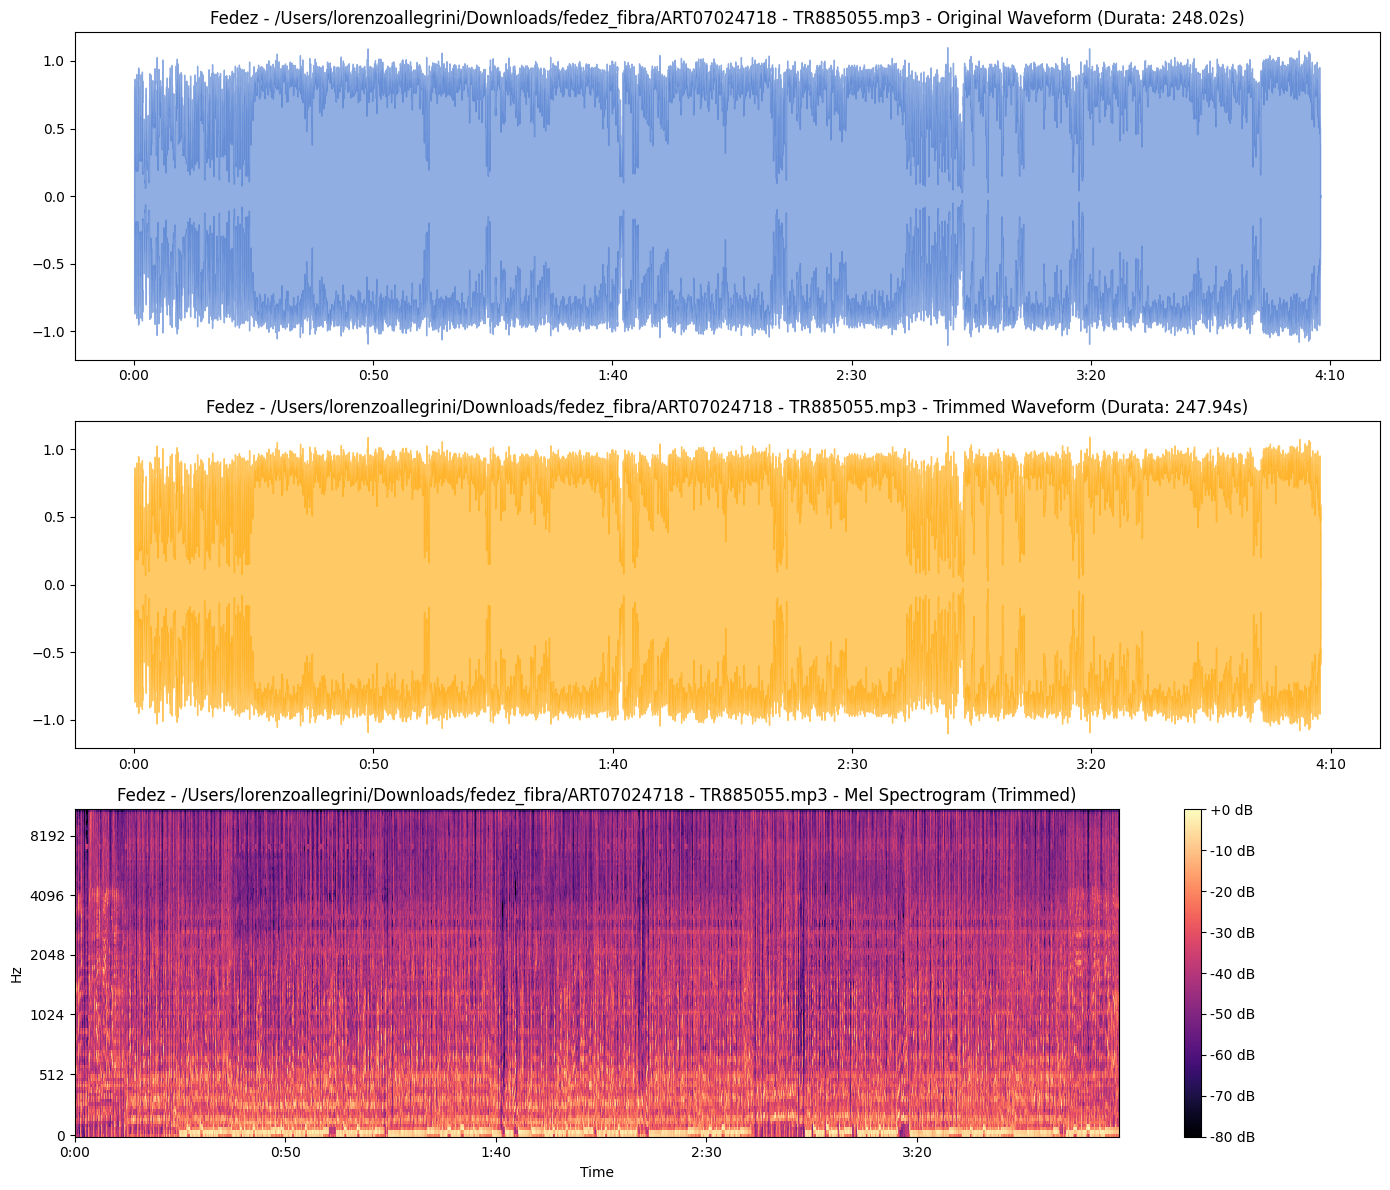

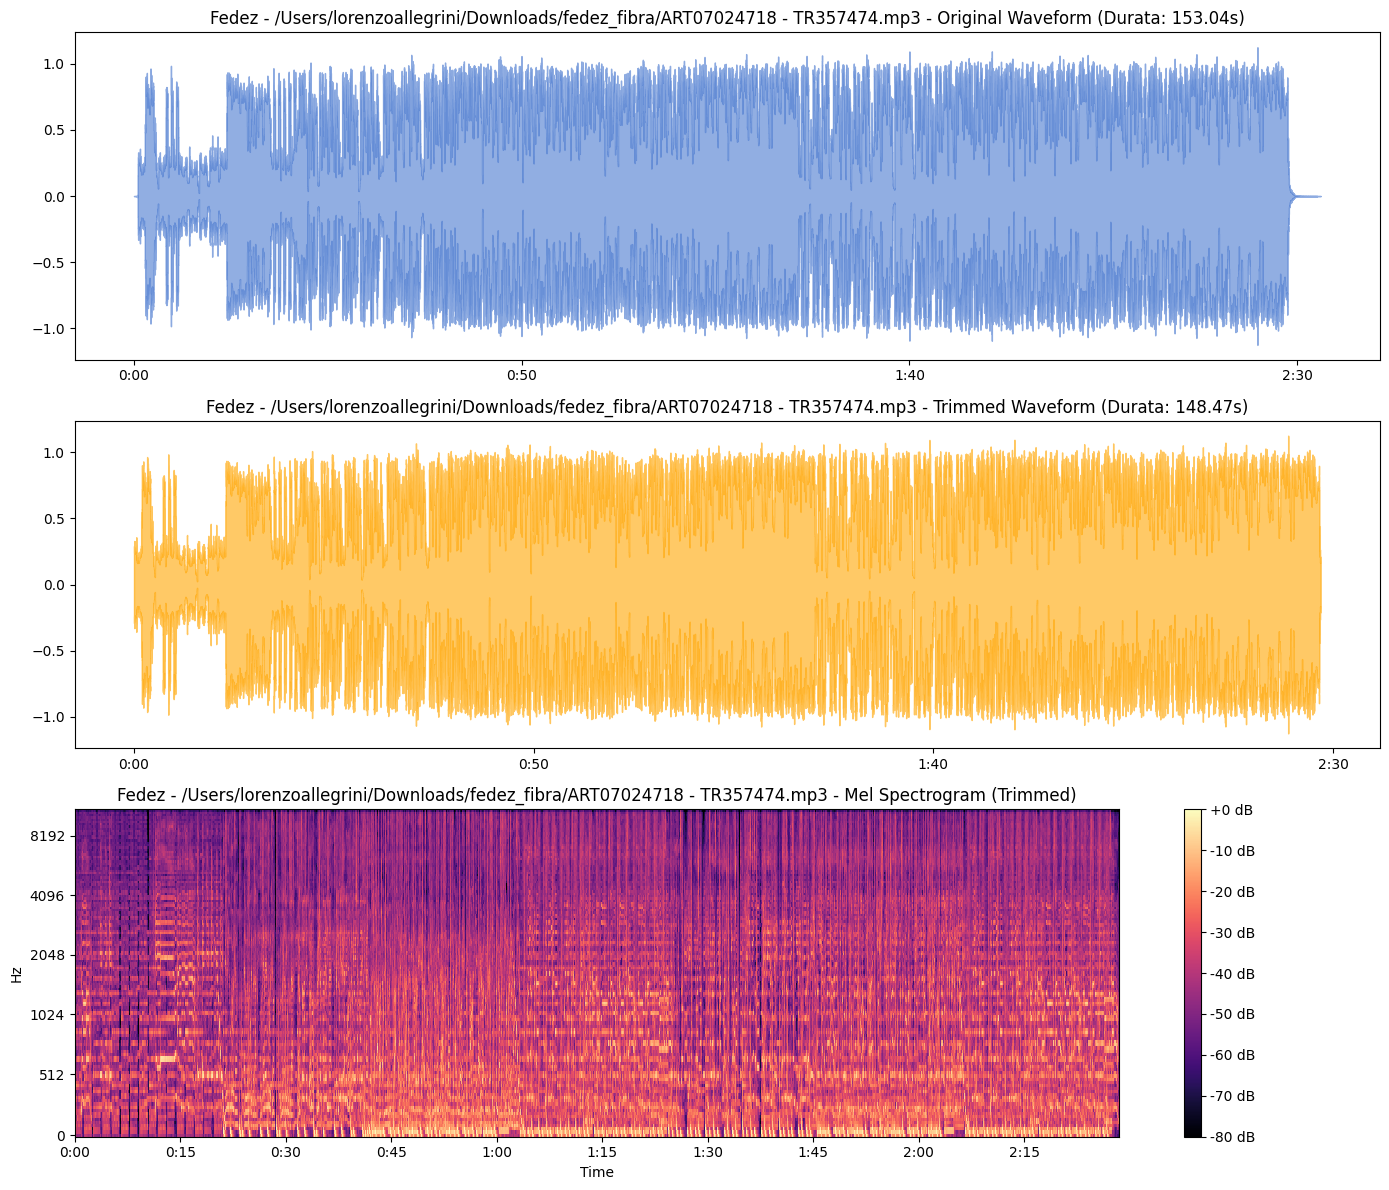

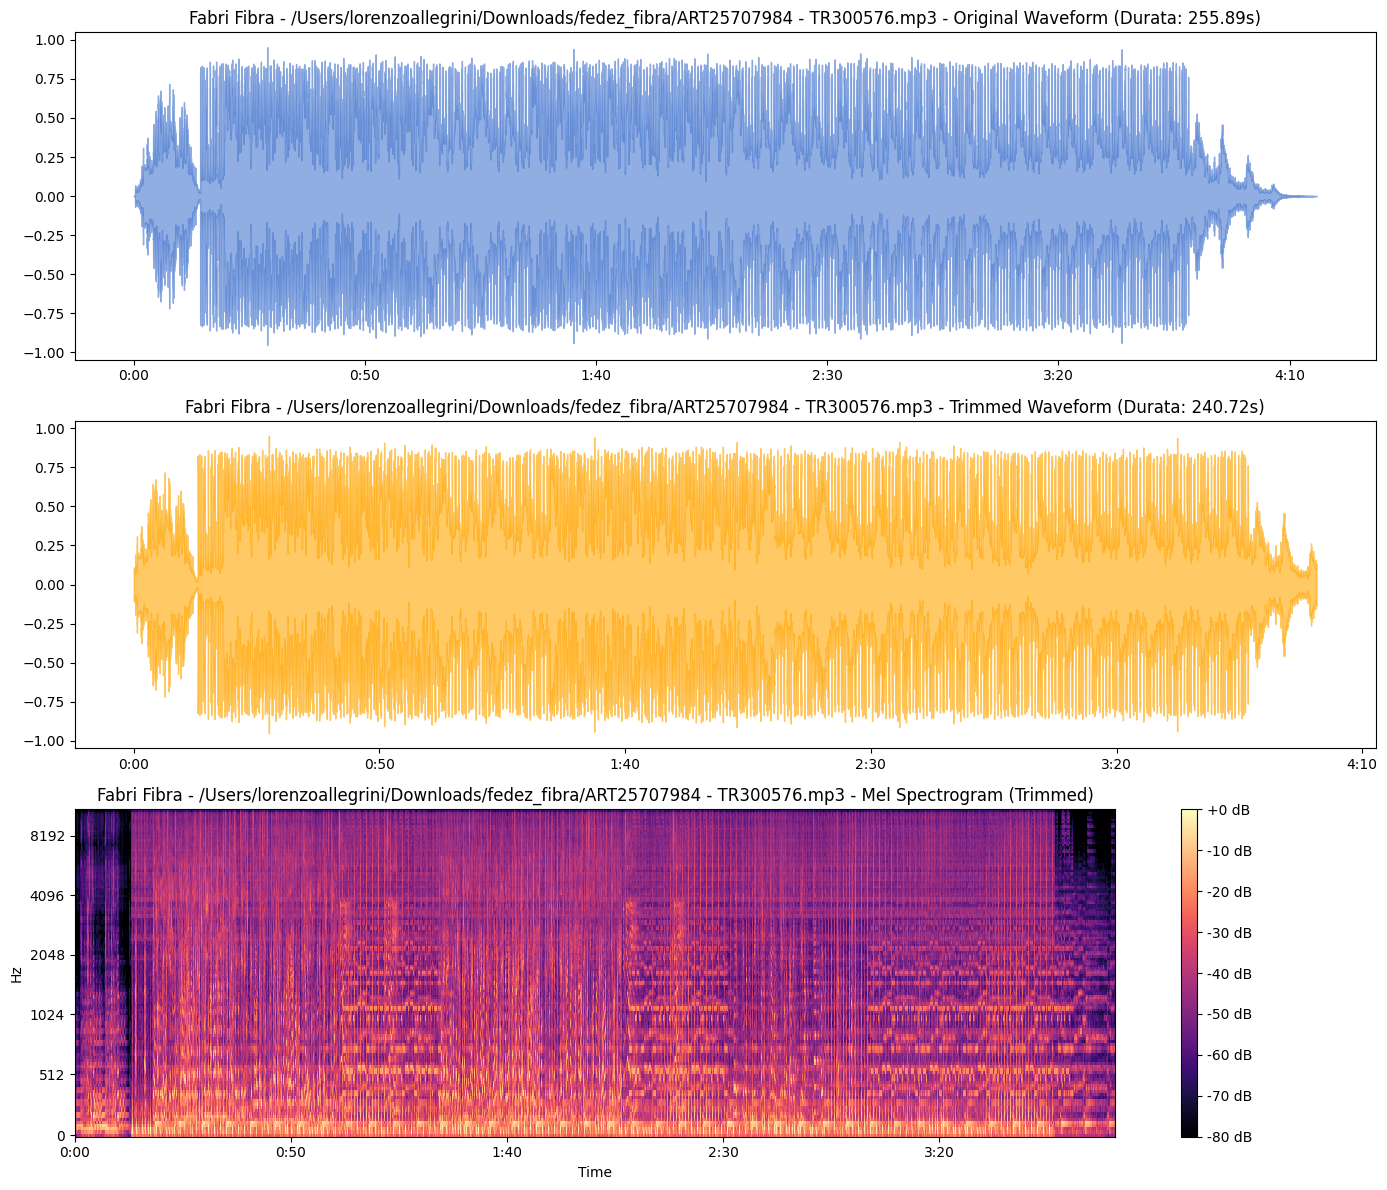

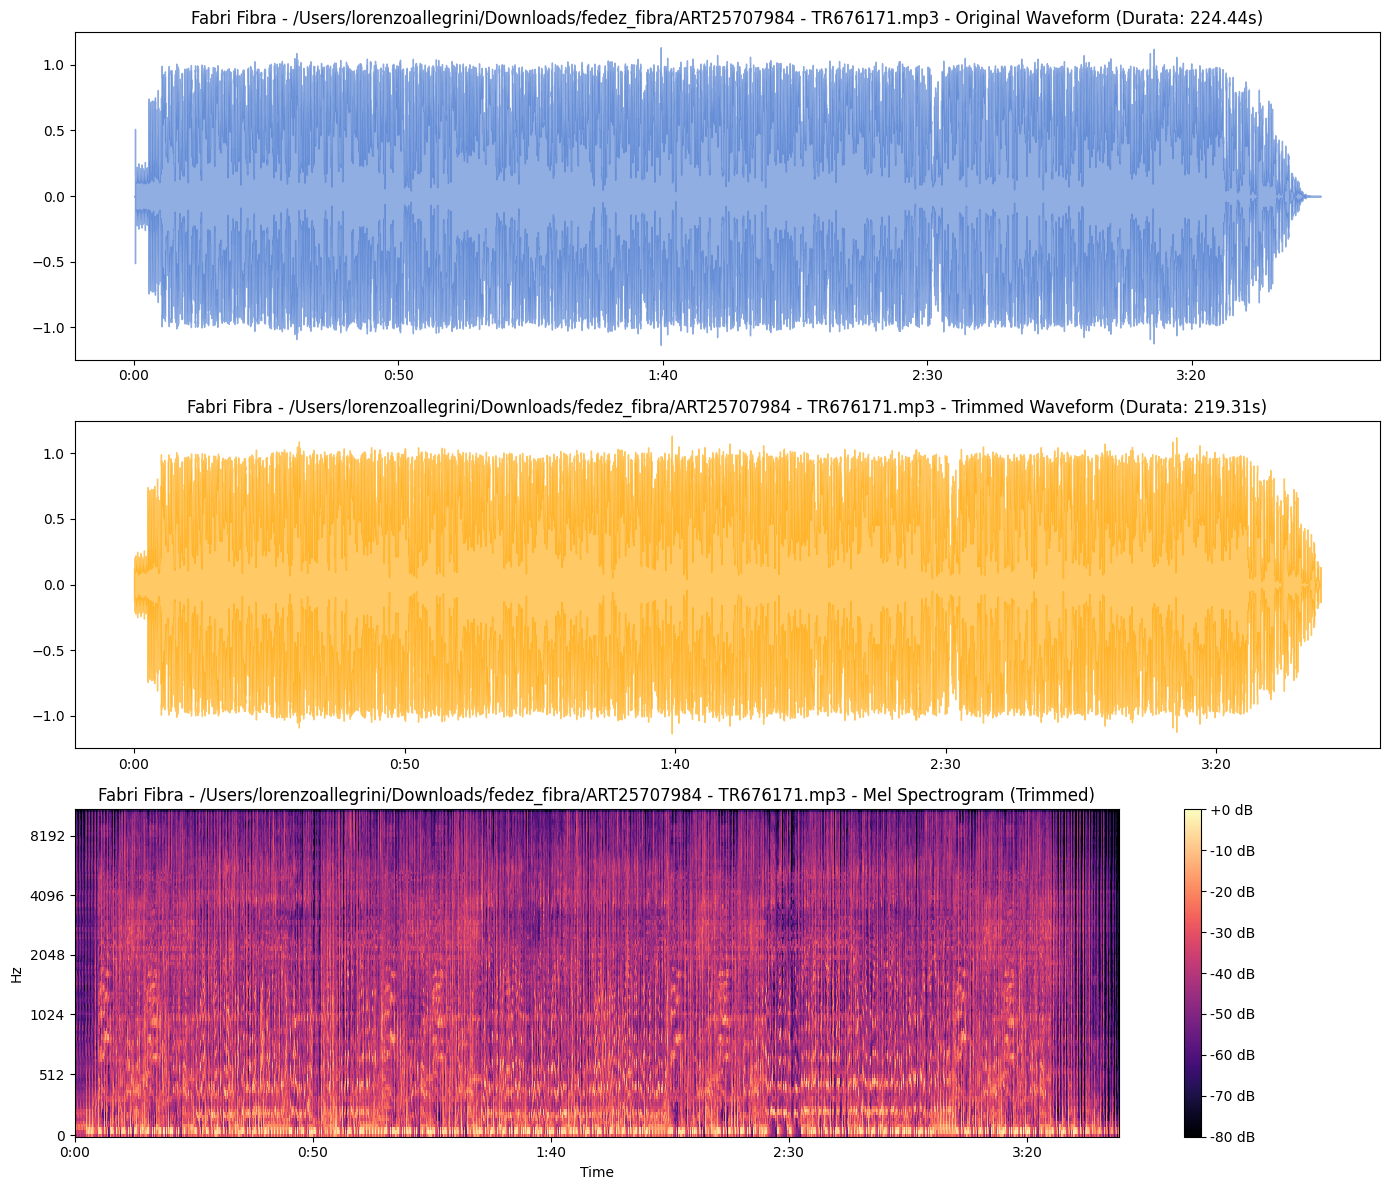

In [4]:
def visualize_audio(file_path, title="Audio Visualization"):
    y, sr = librosa.load(file_path, sr=22050)
    
    y_trimmed, index = librosa.effects.trim(y, top_db=20)
    
    plt.figure(figsize=(14, 12)) 
    
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(y, sr=sr, alpha=0.6)
    plt.title(f"{title} - Original Waveform (Durata: {librosa.get_duration(y=y, sr=sr):.2f}s)")
    plt.xlabel("") # Rimuovo label x per pulizia

    plt.subplot(3, 1, 2)
    librosa.display.waveshow(y_trimmed, sr=sr, color='orange', alpha=0.6)
    plt.title(f"{title} - Trimmed Waveform (Durata: {librosa.get_duration(y=y_trimmed, sr=sr):.2f}s)")
    plt.xlabel("")
    
    plt.subplot(3, 1, 3)
    S = librosa.feature.melspectrogram(y=y_trimmed, sr=sr, n_mels=128)
    S_dB = librosa.power_to_db(S, ref=np.max)
    
    img = librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(img, format='%+2.0f dB')
    plt.title(f"{title} - Mel Spectrogram (Trimmed)")
    
    plt.tight_layout()
    plt.show()

for sample in fedez_files[:2]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fedez - {sample}")

for sample in fibra_files[:2]:
    visualize_audio(os.path.join(MP3_FOLDER, sample), title=f"Fabri Fibra - {sample}")

## 5. Clustering (Task 4.1)
We use **K-Means** with **DTW (Dynamic Time Warping)** or Euclidean distance to group songs.
Since standard DTW is slow, we might use `softdtw` or keep Euclidean if the alignment is already good (since we took middle slice).

Let's try by just using Kmeans on the resampled timeseries

In [5]:
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)

all_data = []
for filename in all_files:
    y, sr = librosa.load(filename, sr=24000)
    resampled_y = resampler.fit_transform(y.reshape(-1, 1))
    all_data.append(resampled_y)

all_data = np.array(all_data)

scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(all_data)

kmeans = TimeSeriesKMeans(
    n_clusters=2,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=True,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(X_scaled)

plot_timeseries_clusters(X_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering Baseline")

KeyboardInterrupt: 

In [ ]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

NameError: name 'predicted_clusters' is not defined

In [20]:
# Estrazione Features
extractor = FeatureExtractor()
all_features = []

for file_path in all_files:
    features = extractor.extract_features(
        file_path=file_path,
        required_len=target_length_samples,
        cache_dir="./extracted_features"  
    )
    all_features.append(features)

# Resampling
target_length = 500
resampler = TimeSeriesResampler(sz=target_length)
X_resampled = resampler.fit_transform(all_features)  # shape: (n_songs, 500, 768)


Loading cached features: ART07024718 - TR885055
Loading cached features: ART07024718 - TR885055
Loading cached features: ART07024718 - TR357474
Loading cached features: ART07024718 - TR357474
Loading cached features: ART07024718 - TR832166
Loading cached features: ART07024718 - TR832166
Loading cached features: ART07024718 - TR106318
Loading cached features: ART07024718 - TR106318
Loading cached features: ART07024718 - TR943991
Loading cached features: ART07024718 - TR943991
Loading cached features: ART07024718 - TR625764
Loading cached features: ART07024718 - TR625764
Loading cached features: ART07024718 - TR824115
Loading cached features: ART07024718 - TR824115
Loading cached features: ART07024718 - TR328499
Loading cached features: ART07024718 - TR328499
Loading cached features: ART07024718 - TR448877
Loading cached features: ART07024718 - TR448877
Loading cached features: ART07024718 - TR802307
Loading cached features: ART07024718 - TR802307
Loading cached features: ART25707984 - T

In [33]:
# Preparazione per PCA (Flattening)
n_songs, n_time, n_feat = X_resampled.shape
X_flat = X_resampled.reshape(n_songs * n_time, n_feat)

# PCA
pca = PCA(n_components=10)
mask = ~np.isnan(X_flat).any(axis=1)

X_valid = X_flat[mask]
X_pca_valid = pca.fit_transform(X_valid)

X_pca_full = np.full((X_flat.shape[0], pca.n_components), np.nan)
X_pca_full[mask] = X_pca_valid

# Reshape e Scaling
X_pca = X_pca_full.reshape(n_songs, n_time, -1)
scaler = TimeSeriesScalerMeanVariance()
X_scaled = scaler.fit_transform(X_pca)

# Clustering
kmeans = TimeSeriesKMeans(
    n_clusters=2,
    metric="dtw",
    max_iter=10,
    n_init=3,
    verbose=True,
    random_state=42
)
predicted_clusters = kmeans.fit_predict(X_scaled)

Init 1


[Parallel(n_jobs=1)]: Done  20 out of  20 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished


4425.330 --> 

[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished
[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished


2972.575 --> 2972.575 --> 
Init 2


...

[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished


2982.566 --> 

[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished


2982.566 --> 


[Parallel(n_jobs=1)]: Done  40 out of  40 | elapsed:    0.1s finished


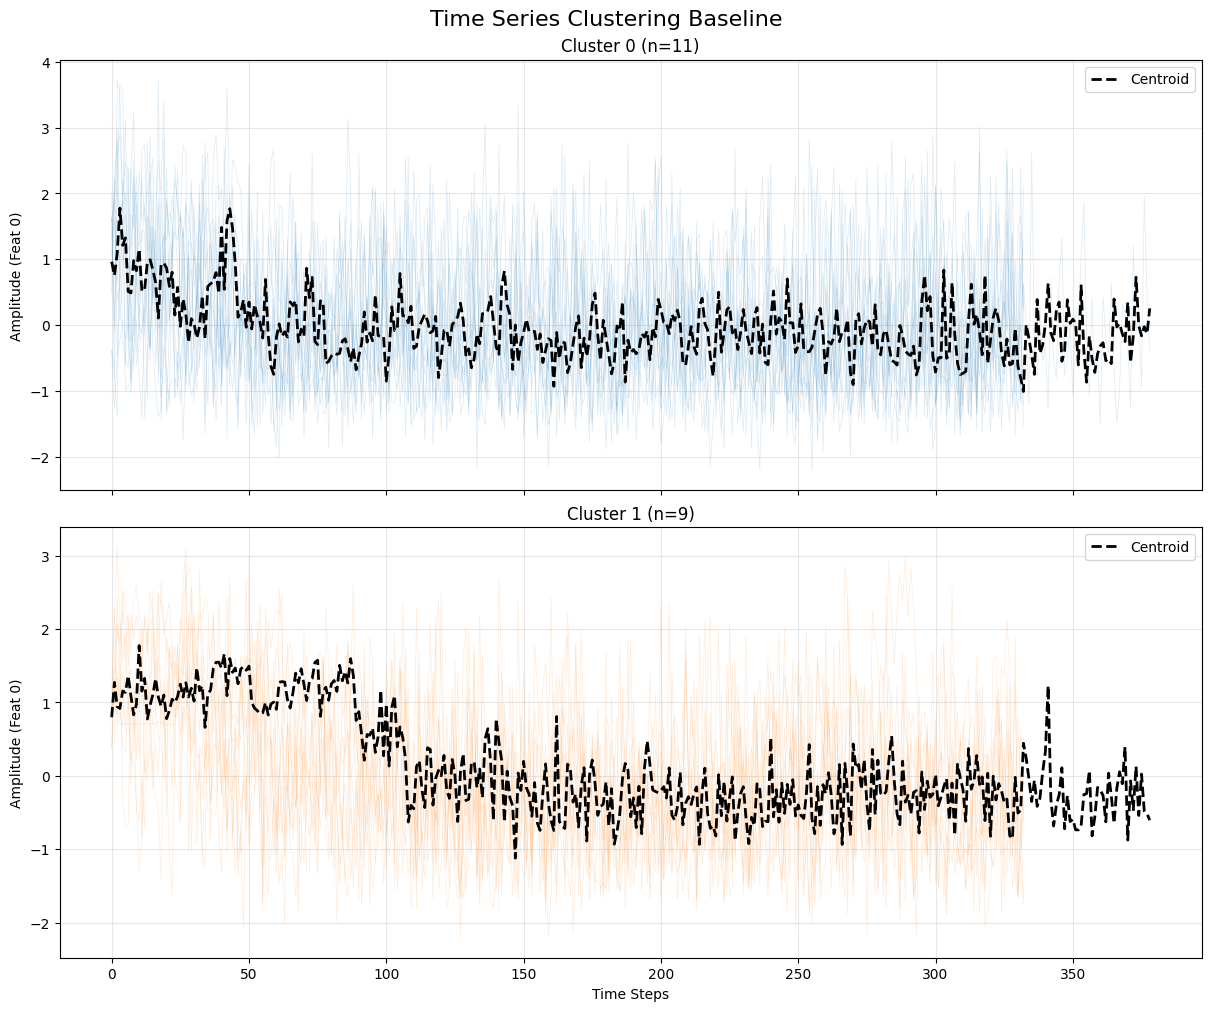

In [34]:
plot_timeseries_clusters(X_scaled, predicted_clusters, centroids=kmeans.cluster_centers_, feature_idx=0, title="Time Series Clustering Baseline")

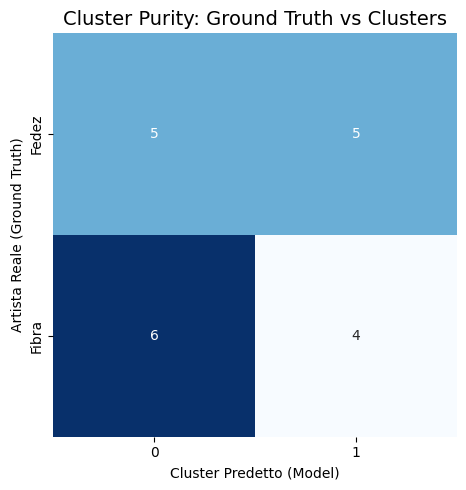

Cluster Predetto (Model),0,1
Artista Reale (Ground Truth),,
Fedez,5,5
Fibra,6,4


In [35]:
true_labels = ["Fedez" if f in fedez_files else "Fibra" for f in all_files]
plot_cluster_purity(true_labels, predicted_clusters)

Feature-based clustering

In [36]:
def calculate_features(values):
    features = {
        'avg': np.mean(values),
        'std': np.std(values),
        'var': np.var(values),
        'med': np.median(values),
        '10p': np.percentile(values, 10),
        '25p': np.percentile(values, 25),
        '50p': np.percentile(values, 50),
        '75p': np.percentile(values, 75),
        '90p': np.percentile(values, 90),
        'iqr': np.percentile(values, 75) - np.percentile(values, 25),
        'cov': 1.0 * np.mean(values) / np.std(values),
        'skw': stats.skew(values),
        'kur': stats.kurtosis(values)
    }

    return features

F = [list(calculate_features(x).values())[:-2] for x in X_scaled]

NameError: name 'stats' is not defined

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=k, n_init=10)
kmeans.fit(F)
predicted_clusters = kmeans.predict(F)
plot_timeseries_clusters(F, predicted_clusters, title="KMeans Clustering")

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
colors = ['#1f77b4', '#ff7f0e']

clusters = kmeans.labels_
audio_data = [X[clusters == i] for i in range(2)]

for i in range(2):
    axes[i].plot(audio_data[i], color=colors[i])
    axes[i].set_title(f'Audio {i+1}')
    axes[i].set_xlabel('Time')
    axes[i].set_ylabel('Amplitude')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=k, n_init=10)
kmeans.fit(F)

### Visualize Centroids (Motifs)
The cluster centroids represent the "average" song in that cluster, effectively capturing the **motif** or common pattern of that group.

In [ ]:
plt.figure(figsize=(12, 6))
for i, centroid in enumerate(km.cluster_centers_):
    plt.subplot(1, 2, i + 1)
    # Visualize first MFCC coefficient (Energy/Loudness approx) and maybe another
    plt.plot(centroid[:, 0], label='MFCC 0 (Loudness)')
    plt.plot(centroid[:, 1], label='MFCC 1 (Timbre)', alpha=0.7)
    plt.title(f"Cluster {i} Centroid")
    plt.legend()
plt.tight_layout()
plt.show()

### Anomaly Detection
We identify anomalies as the songs that are furthest from their cluster centroid.

In [ ]:
# Calculate distances to assigned centroid
distances = []
for i in range(len(X_scaled)):
    cluster_idx = labels[i]
    centroid = km.cluster_centers_[cluster_idx]
    # Euclidean distance
    dist = np.linalg.norm(X_scaled[i] - centroid)
    distances.append(dist)

df_res['Distance'] = distances

# Top 5 Anomalies
anomalies = df_res.sort_values('Distance', ascending=False).head(5)
print("Top 5 Anomalies (Furthest from centroid):")
print(anomalies)

## 6. Shapelet Extraction (Task 4.2)
We use **LearningShapelets** to find shapelets (discriminative subsequences) that best separate Fedez from Fabri Fibra.

In [ ]:
# Prepare labels for classification
le = LabelEncoder()
y_enc = le.fit_transform(y)

# Define Shapelet Model
print("Training Shapelet Model (this may take a while)...")
# Only using a few shapelets for speed demonstration
shp_clf = LearningShapelets(
    n_shapelets_per_size={50: 3}, 
    max_iter=50,
    verbose=1,
    optimizer="adam",
    scale=False,
    random_state=42
)

shp_clf.fit(X_scaled, y_enc)
print("Shapelet training complete.")

# Predictions
y_pred = shp_clf.predict(X_scaled)
print(f"Accuracy: {accuracy_score(y_enc, y_pred):.2f}")

### Visualize Learning Shapelets
We visualize the learned shapelets and where they match in the time series.

In [ ]:
predicted_locations = shp_clf.transform(X_scaled)
shapelet_vis_count = min(3, len(shp_clf.shapelets_as_time_series_))

plt.figure(figsize=(15, 5 * shapelet_vis_count))
for i in range(shapelet_vis_count):
    s = shp_clf.shapelets_as_time_series_[i]
    # Find the best match across all samples
    # transform returns distances. We want to find sample with min distance to this shapelet.
    # Actually transform returns min distances.
    
    # Let's just plot the shapelet itself first (first dimension)
    plt.subplot(shapelet_vis_count, 1, i + 1)
    plt.plot(s[:, 0], label='Shapelet Dim 0 (Loudness)')
    if s.shape[1] > 1:
        plt.plot(s[:, 1], label='Shapelet Dim 1 (Timbre)', alpha=0.6)
    plt.title(f"Shapelet {i}")
    plt.legend()

plt.tight_layout()
plt.show()